In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
matplotlib.rcParams['image.cmap'] = 'gray'

In [191]:
def cartoonify(image, arguments=0):
    # bilateral filter
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurredImg = cv2.GaussianBlur(gray, (5, 5), sigmaX=0, sigmaY=0)
    img_laplace = cv2.bitwise_not(cv2.Laplacian(blurredImg, cv2.CV_8U, ksize=5))
    ret, thresh_bin = cv2.threshold(img_laplace, 150, 255, cv2.THRESH_BINARY)

    thresh_bin = cv2.cvtColor(thresh_bin, cv2.COLOR_GRAY2BGR)
    print(thresh_bin.shape, image.shape)
    cartoonImage = cv2.bitwise_and(image, thresh_bin)

    return cartoonImage

In [206]:
def pencilSketch(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blurredImg = cv2.GaussianBlur(gray, (5, 5), sigmaX=0, sigmaY=0)

    img_laplace = cv2.bitwise_not(cv2.Laplacian(blurredImg, cv2.CV_8U, ksize=5))

    ret, pencilSketchImage = cv2.threshold(img_laplace, 165, 255, cv2.THRESH_BINARY)

    return pencilSketchImage

In [207]:
imagePath = "data/trump.jpg"
image = cv2.imread(imagePath)

pencilSketchImage = pencilSketch(image)
cartoonImage = cartoonify(image)

(573, 500, 3) (573, 500, 3)


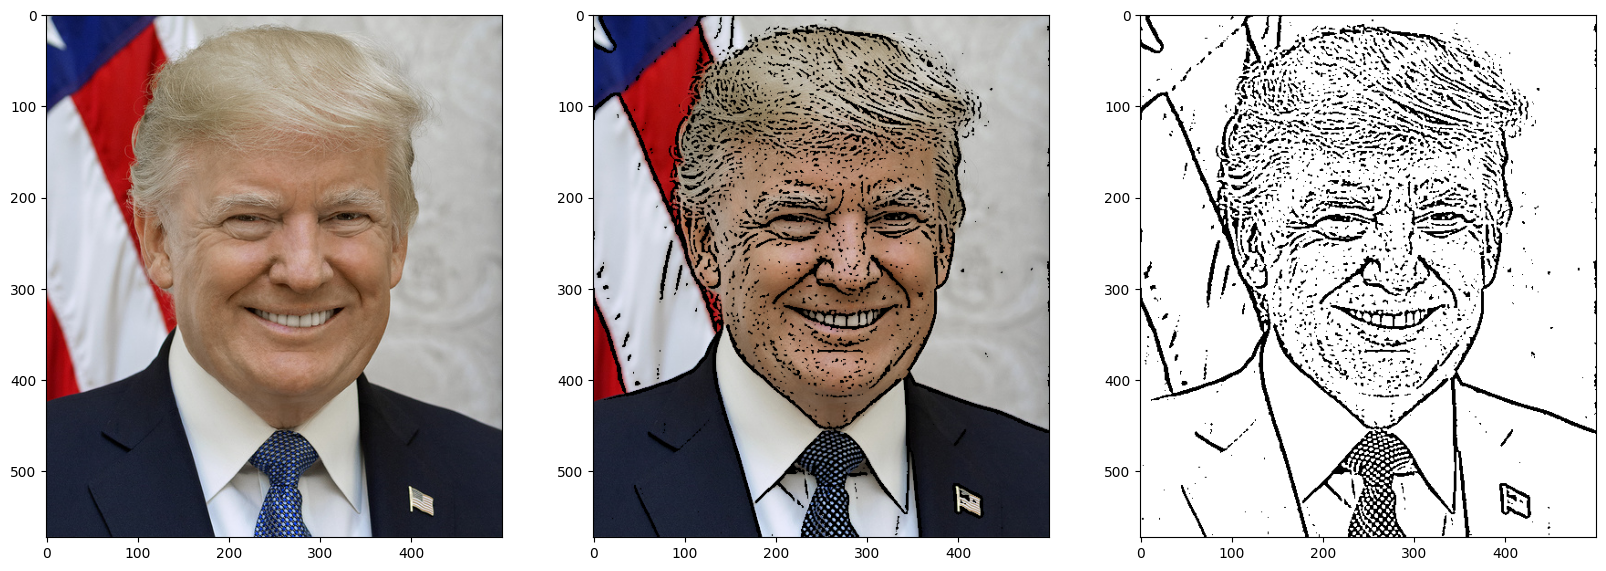

In [208]:
plt.figure(figsize=[20,10])
plt.subplot(131);plt.imshow(image[:,:,::-1]);
plt.subplot(132);plt.imshow(cartoonImage[:,:,::-1]);
plt.subplot(133);plt.imshow(pencilSketchImage, cmap="gray");